In [4]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [5]:

print("--- TASK 1: Dataset Exploration ---")
# Using the raw data link from UCI for the Banknote Authentication Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
col_names = ['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class']
df = pd.read_csv(url, names=col_names)

# Display first 5 rows
print(df.head())
# Shape of dataset
print("Dataset Shape:", df.shape)

print("\n")

# Information
df.info()

print("\n")

# Statistical summary
df.describe()


--- TASK 1: Dataset Exploration ---
   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0
Dataset Shape: (1372, 5)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB




,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [6]:
df.isnull().sum()

,0
Variance,0
Skewness,0
Curtosis,0
Entropy,0
Class,0


Class
0    762
1    610
Name: count, dtype: int64


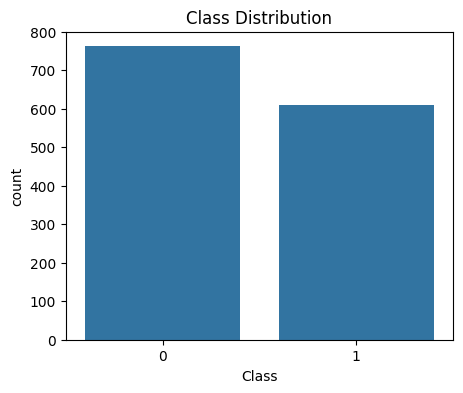

In [7]:
# Count class labels

print(df["Class"].value_counts())

# Plot class distribution

plt.figure(figsize=(5,4))
sns.countplot(x="Class", data=df)

plt.title("Class Distribution")
plt.show()

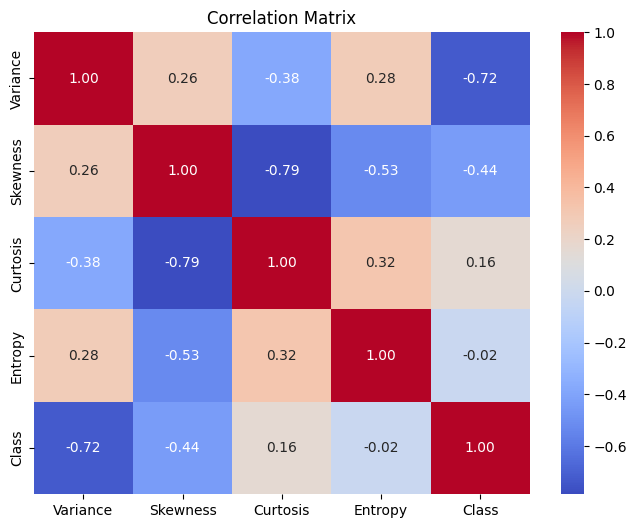

In [8]:
# Compute correlation matrix

correlation_matrix = df.corr()

# Plot heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [9]:
# Separate features and target

X = df.drop("Class", axis=1)

y = df["Class"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (1372, 4)
Target Shape : (1372,)


In [10]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

# Standardize features

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Check first five scaled samples

print(X_train[:5])

Training Samples : 1097
Testing Samples : 275
[[-0.6391558   1.80557961 -0.18836535 -3.05096841]
 [ 0.82188925  0.85239902 -0.59407847  0.60345479]
 [-1.65703344 -1.63328321  2.38386151 -0.34235536]
 [ 1.72886098  0.32863093 -0.74807722  1.08444894]
 [ 0.11397258  0.2059923   0.32509151  0.53465595]]


In [11]:
class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs

        self.weights = None
        self.bias = None

        # NEW: Store training history
        self.errors = []
        self.weight_history = []
        self.bias_history = []

    def activation(self, x):
        if x >= 0:
            return 1
        else:
            return 0
    def fit(self, X, y):

      # Number of samples and features
      n_samples, n_features = X.shape

      # Initialize weights and bias
      self.weights = np.zeros(n_features)
      self.bias = 0

      # Store history for plots
      self.errors = []
      self.weight_history = []
      self.bias_history = []

      # Training starts
      for epoch in range(self.epochs):

          epoch_errors = 0

          for i in range(n_samples):

              # Forward Propagation
              linear_output = np.dot(X[i], self.weights) + self.bias

              prediction = self.activation(linear_output)

              # Perceptron Learning Rule
              update = self.learning_rate * (y.iloc[i] - prediction)

              # Update weights and bias
              self.weights += update * X[i]
              self.bias += update

              # Count misclassified samples
              if update != 0:
                  epoch_errors += 1

          # Store history
          self.errors.append(epoch_errors)
          self.weight_history.append(self.weights.copy())
          self.bias_history.append(self.bias)

          # -------- TASK 5 DISPLAY --------
          print(f"\nEpoch {epoch+1}/{self.epochs}")
          print(f"Misclassified Samples : {epoch_errors}")
          print(f"Updated Weights : {self.weights}")
          print(f"Updated Bias : {self.bias}")

    def predict(self, X):

        linear_output = np.dot(X, self.weights) + self.bias

        predictions = []

        for value in linear_output:
            predictions.append(self.activation(value))

        return np.array(predictions)

In [12]:
# Create the Perceptron model

model = Perceptron(
    learning_rate=0.01,
    epochs=20
)

# Train the model

model.fit(X_train, y_train)

print("Training Completed!")



Epoch 1/20
Misclassified Samples : 47
Updated Weights : [-0.06920384 -0.06634441 -0.06529563 -0.00524322]
Updated Bias : -0.03

Epoch 2/20
Misclassified Samples : 22
Updated Weights : [-0.07576842 -0.09439477 -0.05170347 -0.00312988]
Updated Bias : -0.03

Epoch 3/20
Misclassified Samples : 28
Updated Weights : [-0.08628609 -0.10389484 -0.06133036 -0.00617938]
Updated Bias : -0.03

Epoch 4/20
Misclassified Samples : 24
Updated Weights : [-0.09820347 -0.0939408  -0.08818487 -0.01037106]
Updated Bias : -0.05

Epoch 5/20
Misclassified Samples : 29
Updated Weights : [-0.10984895 -0.12095156 -0.08618021  0.0003308 ]
Updated Bias : -0.04

Epoch 6/20
Misclassified Samples : 17
Updated Weights : [-0.10385459 -0.13004831 -0.08702307  0.01372732]
Updated Bias : -0.05

Epoch 7/20
Misclassified Samples : 26
Updated Weights : [-0.10982533 -0.11869946 -0.11825568 -0.01997855]
Updated Bias : -0.05

Epoch 8/20
Misclassified Samples : 19
Updated Weights : [-0.12265141 -0.13640219 -0.09861007 -0.0118441

In [13]:
# Predict test data

predictions = model.predict(X_test)

print(predictions[:10])

from sklearn.metrics import accuracy_score

# Calculate accuracy

accuracy = accuracy_score(y_test, predictions)

print("Accuracy :", accuracy)

[0 0 0 0 0 0 0 0 0 0]
Accuracy : 0.9818181818181818


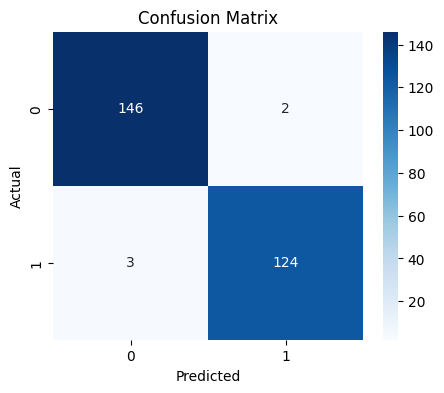

In [14]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [15]:
from sklearn.metrics import classification_report

# Classification Report

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       148
           1       0.98      0.98      0.98       127

    accuracy                           0.98       275
   macro avg       0.98      0.98      0.98       275
weighted avg       0.98      0.98      0.98       275



In [16]:
# Display learned weights and bias

print("Weights:")
print(model.weights)

print("\nBias:")
print(model.bias)

Weights:
[-0.15666011 -0.1846127  -0.14009741 -0.01316945]

Bias:
-0.07


In [17]:
# Compare different learning rates

learning_rates = [0.1, 0.01, 0.001]
accuracies = []

for lr in learning_rates:

    model = Perceptron(
        learning_rate=lr,
        epochs=100
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    accuracies.append(accuracy)

    print(f"Learning Rate: {lr} --> Accuracy: {accuracy:.4f}")


Epoch 1/100
Misclassified Samples : 47
Updated Weights : [-0.69203839 -0.66344408 -0.65295627 -0.05243218]
Updated Bias : -0.30000000000000004

Epoch 2/100
Misclassified Samples : 22
Updated Weights : [-0.75768416 -0.94394765 -0.51703472 -0.03129882]
Updated Bias : -0.30000000000000004

Epoch 3/100
Misclassified Samples : 28
Updated Weights : [-0.86286087 -1.03894844 -0.61330355 -0.06179376]
Updated Bias : -0.30000000000000004

Epoch 4/100
Misclassified Samples : 24
Updated Weights : [-0.98203474 -0.93940797 -0.88184872 -0.10371057]
Updated Bias : -0.5

Epoch 5/100
Misclassified Samples : 29
Updated Weights : [-1.09848954 -1.20951565 -0.86180207  0.003308  ]
Updated Bias : -0.4

Epoch 6/100
Misclassified Samples : 17
Updated Weights : [-1.03854586 -1.30048307 -0.87023075  0.13727316]
Updated Bias : -0.5

Epoch 7/100
Misclassified Samples : 26
Updated Weights : [-1.09825326 -1.18699464 -1.18255679 -0.19978554]
Updated Bias : -0.5

Epoch 8/100
Misclassified Samples : 19
Updated Weights 

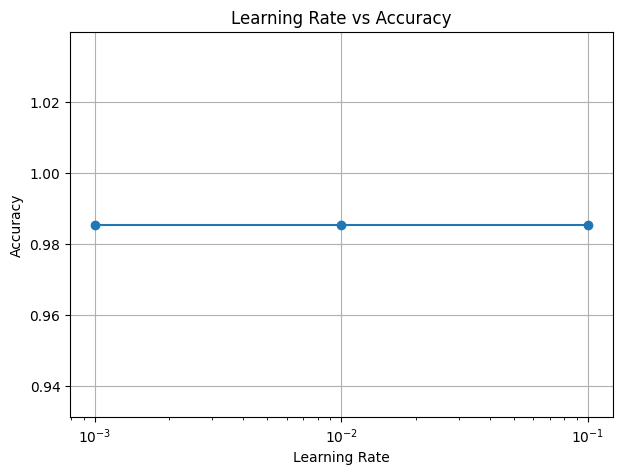

Best Learning Rate : 0.1
Best Accuracy : 0.9854545454545455


In [18]:
plt.figure(figsize=(7,5))

plt.plot(
    learning_rates,
    accuracies,
    marker='o'
)

plt.xscale("log")

plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")

plt.title("Learning Rate vs Accuracy")

plt.grid(True)

plt.show()

best_index = np.argmax(accuracies)

print("Best Learning Rate :", learning_rates[best_index])

print("Best Accuracy :", accuracies[best_index])

<Figure size 1200x800 with 0 Axes>

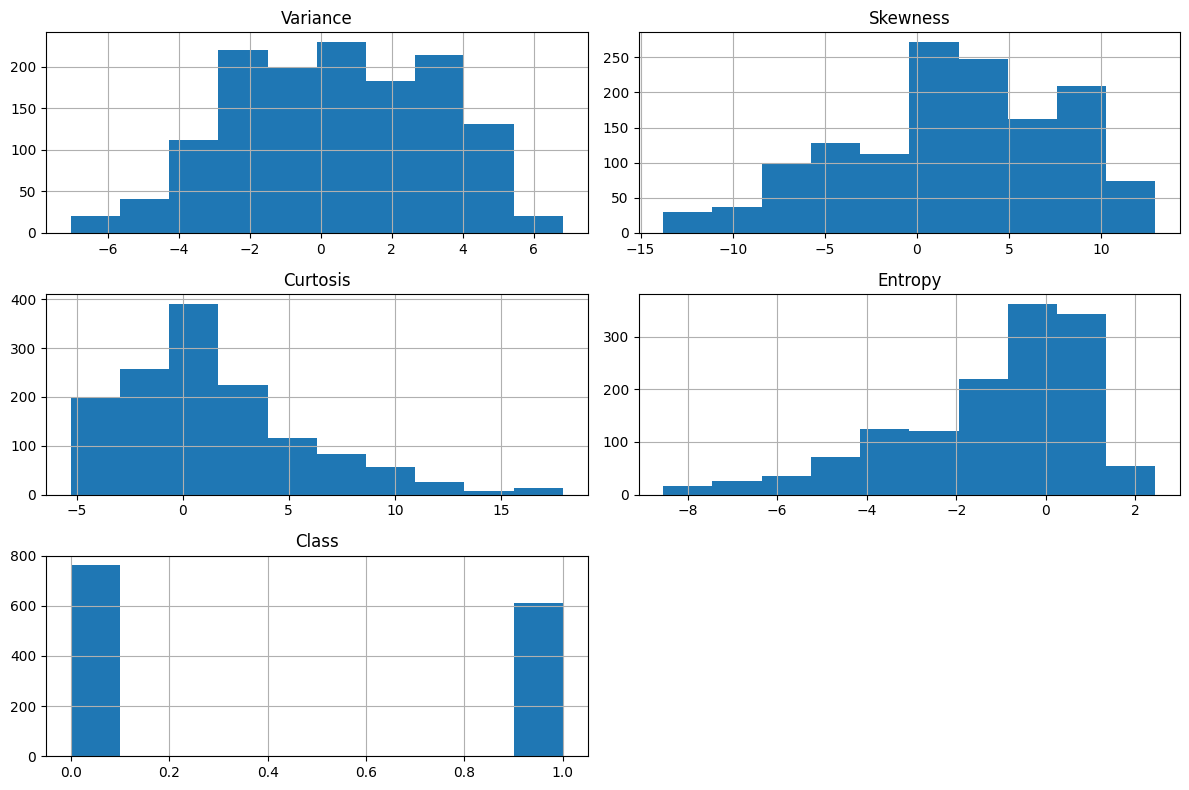

In [19]:
plt.figure(figsize=(12,8))

df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

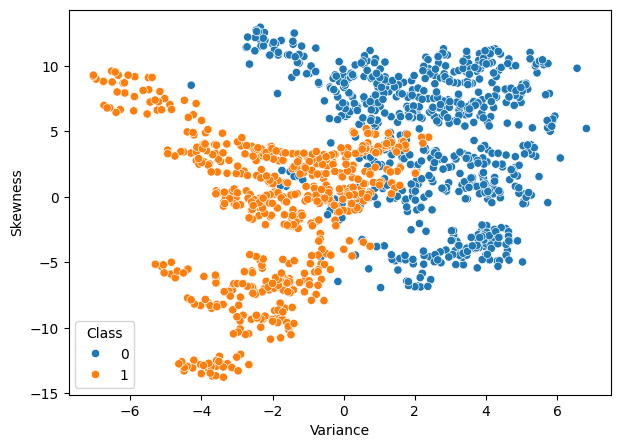

In [20]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="Variance",
    y="Skewness",
    hue="Class",
    data=df
)

plt.show()

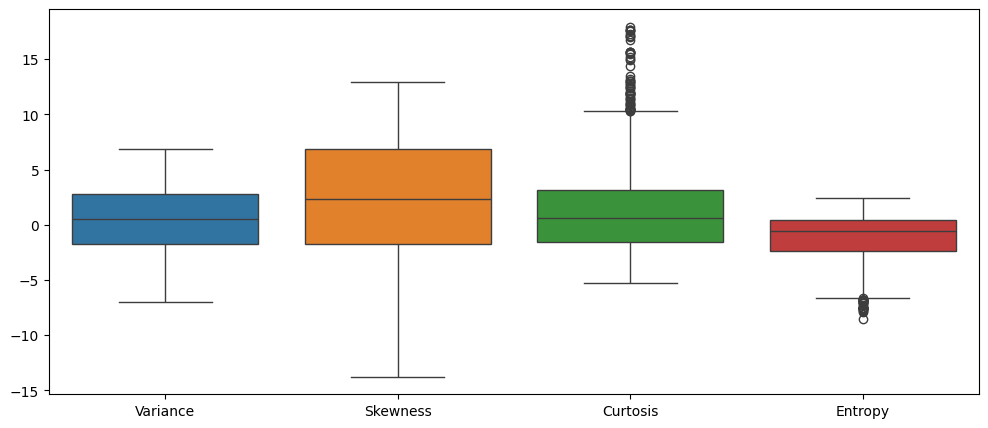

In [21]:
plt.figure(figsize=(12,5))

sns.boxplot(data=df.iloc[:, :-1])

plt.show()

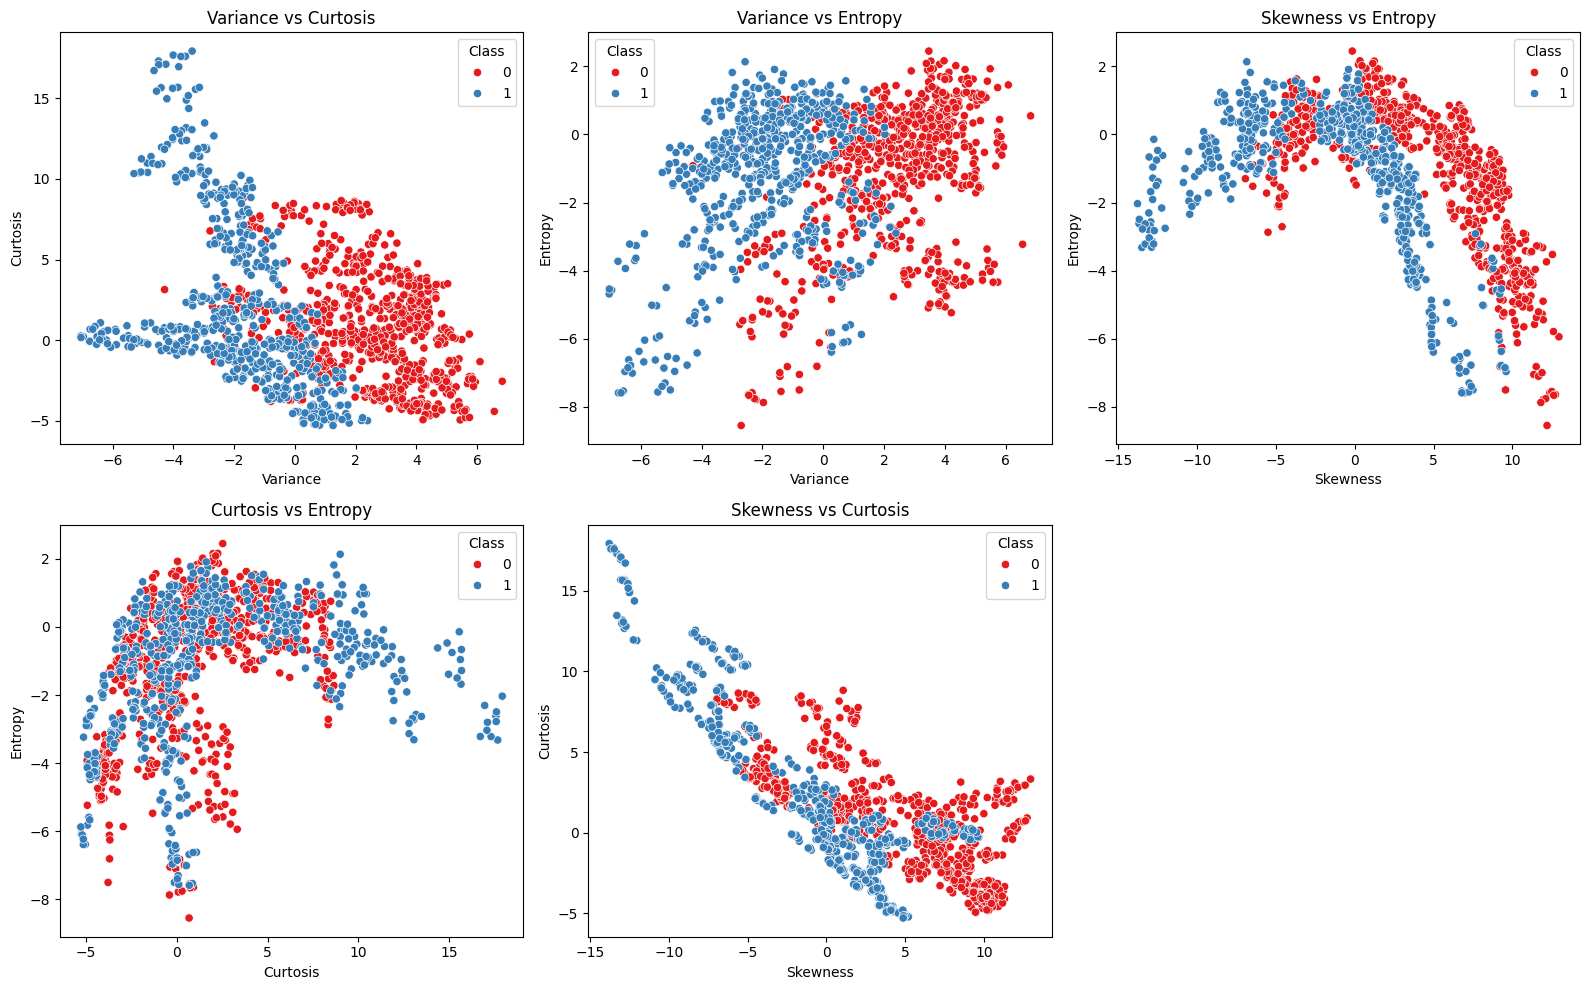

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

pairs = [
    ('Variance', 'Curtosis'),
    ('Variance', 'Entropy'),
    ('Skewness', 'Entropy'),
    ('Curtosis', 'Entropy'),
    ('Skewness', 'Curtosis'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (x_feat, y_feat) in enumerate(pairs):
    sns.scatterplot(data=df, x=x_feat, y=y_feat, hue='Class',
                     palette='Set1', ax=axes[i])
    axes[i].set_title(f'{x_feat} vs {y_feat}')

# hide the unused 6th subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [23]:
print("""
Conclusion

1. The Single Layer Perceptron was successfully implemented from scratch.

2. The model was trained using the Banknote Authentication dataset.

3. Feature scaling improved convergence speed.

4. The Perceptron successfully classified banknotes with high accuracy.

5. Learning rate significantly influenced model performance.

6. A moderate learning rate provided the best balance between speed and stability.
""")


Conclusion

1. The Single Layer Perceptron was successfully implemented from scratch.

2. The model was trained using the Banknote Authentication dataset.

3. Feature scaling improved convergence speed.

4. The Perceptron successfully classified banknotes with high accuracy.

5. Learning rate significantly influenced model performance.

6. A moderate learning rate provided the best balance between speed and stability.

